## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
import os
os.chdir(r'C:\Users\AnuragS\OneDrive\cv_project\2 Stage Loan Approval & Validation System\data')
os.getcwd()

'C:\\Users\\AnuragS\\OneDrive\\cv_project\\2 Stage Loan Approval & Validation System\\data'

## Data Fetch

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


**Rows & Columns**

In [4]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 4269
Columns: 13


**Data Info**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


There is some space issue in the column name. Except loan_id all the columns have initial space.

In [6]:
print('--Columns Before Strip--')
print(df.columns)

df.columns = df.columns.str.strip()

print(' ')
print('--Columns Before Strip--')
print(df.columns)

--Columns Before Strip--
Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')
 
--Columns Before Strip--
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


## Checking Null Values

In [7]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

So no null value is presented

## Statistical Description

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


Here we can see that Residential Asset value is -ve, which is logically not possible.

## Distribution of Approved & Rejected Loans (Overall)

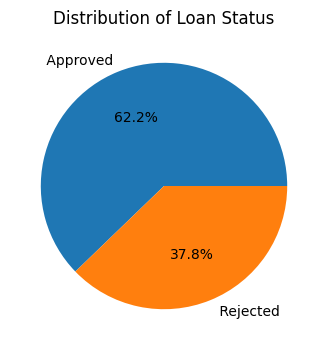

In [7]:
df_loan_status_dist = pd.DataFrame(df['loan_status'].value_counts(normalize=True)).reset_index()


plt.figure(figsize=(14,4))

plt.pie(
    df_loan_status_dist['proportion'],
    autopct='%1.1f%%',
    labels=df_loan_status_dist['loan_status']
    )
plt.title('Distribution of Loan Status')
#plt.legend(loan_status_dist['loan_status'])

plt.show()

**Approved Loans:** 62.2% <br>
**Rejected Loans:** 37.8%

### Analysis of -ve values of Ressidential Asset Values

In [15]:
df_neg_res_asst = df[df['residential_assets_value'] < 0]

print(f'Rows with -ve Residential Asset Value: {df_neg_res_asst.shape[0]}')
print(f'Percentage of data with -ve Residential Asset Value: {round((df_neg_res_asst.shape[0]/df.shape[0])*100)}')
print(f'Unique values when the Residential Asset Values is -ve: {df_neg_res_asst['residential_assets_value'].unique()}')
print('Distribution of Loan Status for the -ve values')
print(' ')
print(f'{df_neg_res_asst['loan_status'].value_counts(normalize=True)*100}')

Rows with -ve Residential Asset Value: 28
Percentage of data with -ve Residential Asset Value: 1
Unique values when the Residential Asset Values is -ve: [-100000]
Distribution of Loan Status for the -ve values
 
loan_status
Approved    57.142857
Rejected    42.857143
Name: proportion, dtype: float64


* A total of **28 records (1% of the dataset)** were found to have negative values in `residential_assets_value`.

* All affected records contained the same value, **-100000**, suggesting that it is a placeholder for missing or unavailable data rather than a valid asset value.

* The loan status distribution for these records (**57.14% Approved, 42.86% Rejected**) was broadly similar to the overall dataset distribution (**62% Approved, 38% Rejected**), indicating no strong bias toward a particular loan outcome.

* Based on this evidence, **-100000 was treated as a missing-value indicator and will replaced with the median of `residential_assets_value`**, as the median is more robust to the variable's right-skewed distribution.

In [14]:
df['residential_assets_value'] = (df['residential_assets_value'].replace(-100000, np.nan))
df['residential_assets_value'] = df['residential_assets_value'].fillna(df['residential_assets_value'].median())

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.510658e+06,6.476129e+06,0.0,2200000.0,5700000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


### Column Segmentation

In [16]:
num_cols = list(pd.DataFrame(df.describe().T.reset_index())['index'].unique())
num_cols = [col for col in num_cols if col != 'loan_id']

cat_cols = [col for col in df.columns if col not in num_cols]
cat_cols = [col for col in cat_cols if col != 'loan_id']

print(f'Numerical Columns: {num_cols}')
print(f'Categorical Columns: {cat_cols}')

Numerical Columns: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical Columns: ['education', 'self_employed', 'loan_status']


**Distribution of Numerical Columns**

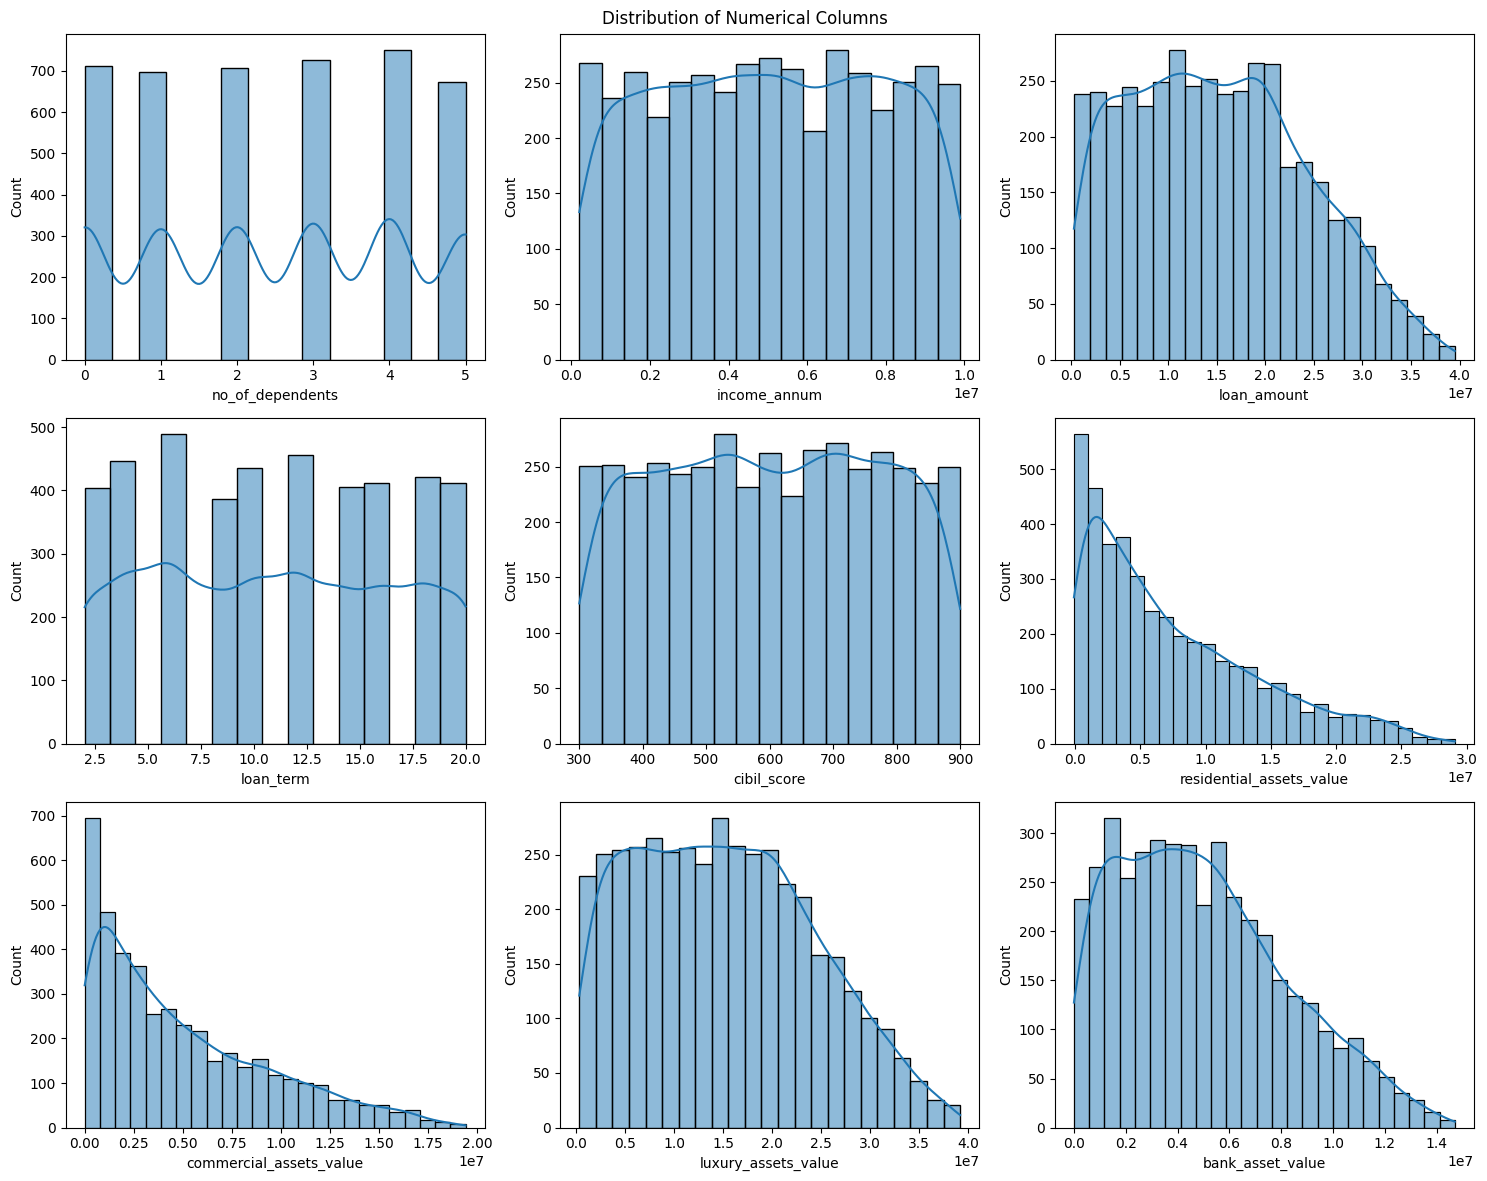

In [17]:
n_cols =  3
n_plot = len(num_cols)
n_rows = math.ceil(n_plot/n_cols)

fig,axes = plt.subplots(ncols=n_cols,nrows=n_rows,figsize=(15, 4*n_rows))
plt.suptitle('Distribution of Numerical Columns')

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(x=df[col], kde=True, ax=axes[i])
    # axes[i].set_title(col)

# Remove unused subplot(s)
for j in range(n_plot, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. Most of the applicants have lower residential, luxury and commercial asset value
2. Income values appear evenly spread from low to high incomes (Mean ≈ Median)
3. Most applicants request smaller-to-medium loan amounts.

**Check Outliers**

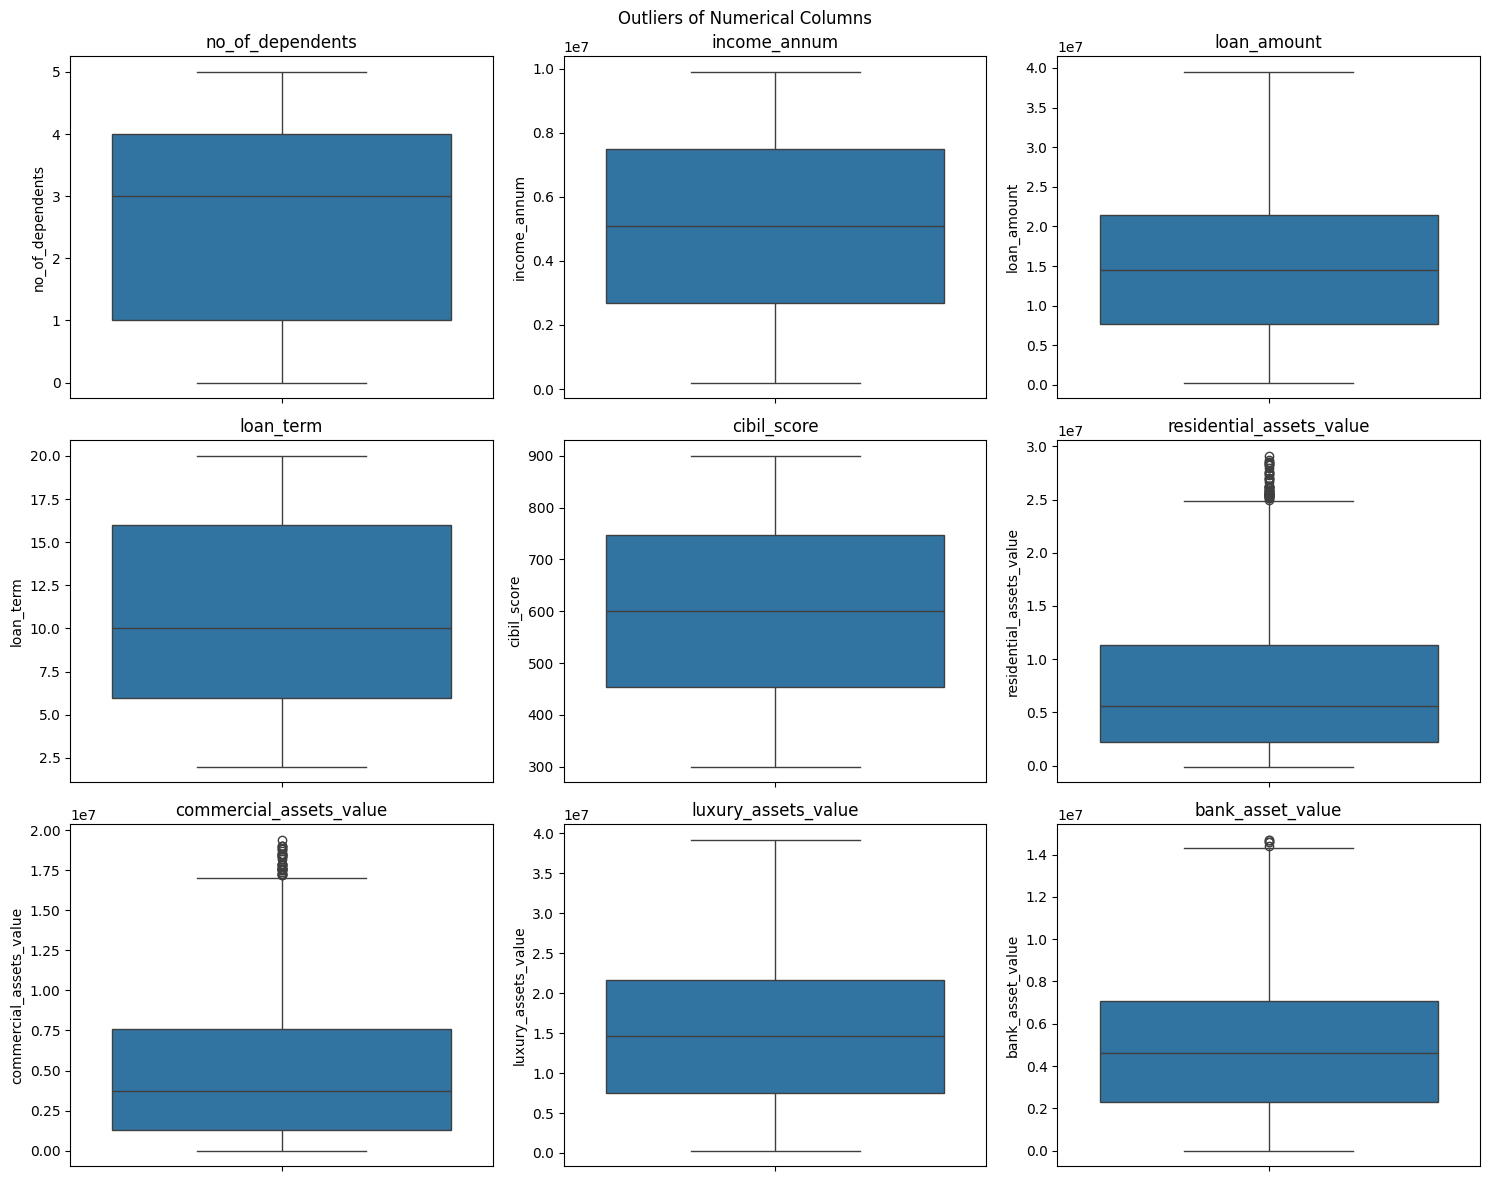

In [18]:
n_cols =  3
n_plot = len(num_cols)
n_rows = math.ceil(n_plot/n_cols)

fig,axes = plt.subplots(ncols=n_cols,nrows=n_rows,figsize=(15, 4*n_rows))
plt.suptitle('Outliers of Numerical Columns')

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove unused subplot(s)
for j in range(n_plot, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Asset Value Outlier Analysis**

In [19]:
asset_value_cols = [col for col in num_cols if 'asset' in col]
asset_value_cols

['residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

In [20]:
asset_col_analysis = []

for col in asset_value_cols:
    pctl99 = df[col].quantile(0.99)
    max_val = df[col].max()
    pct_diff = ((max_val-pctl99)/pctl99*100).round(2)

    asset_col_analysis.append(
        {
        'Asset Columns': col,
        'Maximu Value': max_val,
        '99 Percentile Value':pctl99,
        "Pct difference" :pct_diff
    }
    )

df_asset_col_analysis = pd.DataFrame(asset_col_analysis)

df_asset_col_analysis


,Asset Columns,Maximu Value,99 Percentile Value,Pct difference
0,residential_assets_value,29100000,25400000.0,14.57
1,commercial_assets_value,19400000,16732000.0,15.95
2,luxury_assets_value,39200000,36032000.0,8.79
3,bank_asset_value,14700000,13100000.0,12.21


In [21]:
for col in asset_value_cols:
    pctl99 = df[col].quantile(0.99)
    print(f'----{col}----')
    print(f'{round(df[df[col] > pctl99]['loan_status'].value_counts(normalize=True)*100,2)}')
    print(f' ')

----residential_assets_value----
loan_status
Approved    67.5
Rejected    32.5
Name: proportion, dtype: float64
 
----commercial_assets_value----
loan_status
Approved    51.16
Rejected    48.84
Name: proportion, dtype: float64
 
----luxury_assets_value----
loan_status
Approved    69.77
Rejected    30.23
Name: proportion, dtype: float64
 
----bank_asset_value----
loan_status
Approved    58.54
Rejected    41.46
Name: proportion, dtype: float64
 


* Asset-related variables (`residential_assets_value`, `commercial_assets_value`, `luxury_assets_value`, and `bank_asset_value`) were initially identified as containing potential outliers using statistical methods.

* Further investigation showed that the maximum values were only **9%–16% higher than their respective 99th percentile values**, indicating a smooth upper tail rather than isolated extreme observations.

* This suggests that the high values are likely part of the natural distribution of applicant wealth and are not indicative of data quality issues.

* The overall dataset consists of approximately **62% approved loans and 38% rejected loans**, which was used as the baseline for comparison.

* To assess the business significance of the extreme values, applicants with asset values above the **99th percentile** were analyzed separately.

* The analysis revealed the following approval rates among the top 1% of asset holders:

  * **Residential asset values:** 67.5% approved vs. 62% overall approval
  * **Luxury asset values:** 69.77% approved vs. 62% overall approval
  * **Bank asset values:** 58.54% approved, which is close to the overall approval rate
  * **Commercial asset values:** 51.16% approved, indicating a weaker relationship with loan approval

* The higher approval rates observed for residential and luxury asset holders suggest that these extreme values contain meaningful predictive information rather than representing anomalous records.

* Based on both the statistical analysis and the observed relationship with loan approval, the extreme values were considered valid observations and were **retained in the dataset without capping or removal**.


## Analysis

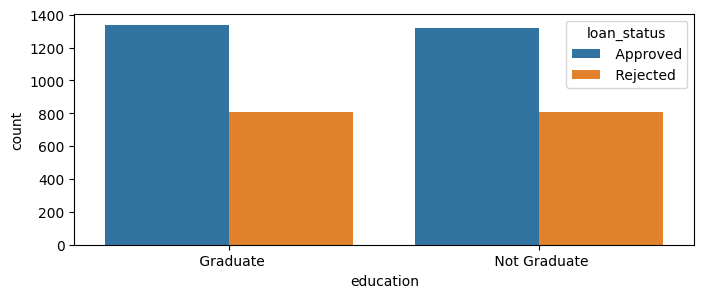

In [25]:
plt.figure(figsize=(8,3))
sns.countplot(data=df,x='education',hue='loan_status')
plt.show()

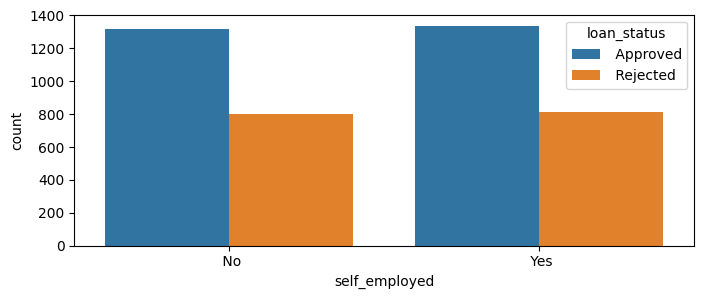

In [26]:
plt.figure(figsize=(8,3))
sns.countplot(data=df,x='self_employed',hue='loan_status')
plt.show()

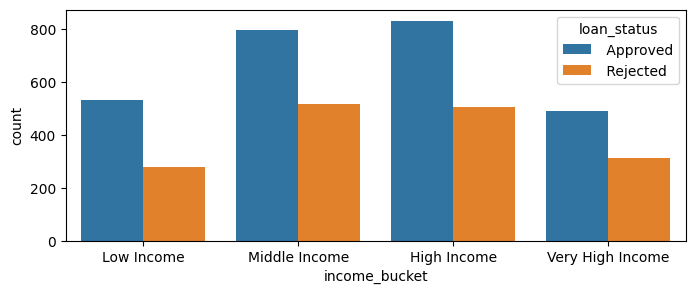

In [27]:
bins = [0, 2000000, 5000000, 8000000, float('inf')]

labels = ['Low Income','Middle Income','High Income','Very High Income']

df['income_bucket'] = pd.cut(
    df['income_annum'],
    bins=bins,
    labels=labels,
    include_lowest=True
)


plt.figure(figsize=(8,3))
sns.countplot(data=df,x='income_bucket',hue='loan_status')
plt.show()


In [28]:
pd.crosstab(
    df['income_bucket'],
    df['loan_status'],
    normalize='index'
).round(4) * 100

loan_status,Approved,Rejected
income_bucket,,
Low Income,65.76,34.24
Middle Income,60.76,39.24
High Income,62.16,37.84
Very High Income,61.12,38.88
